# Chapter 76 — Byte Pair Encoding From Scratch

Chapter 75 showed that character tokens create long sequences.

This chapter learns larger reusable pieces by repeatedly merging frequent adjacent tokens.

## Learning goals

By the end of this chapter, you will be able to:

- explain character-initialized BPE-style training;
- count adjacent token pairs;
- apply a deterministic tie-break;
- merge non-overlapping pair occurrences;
- train and print an ordered merge list;
- track cumulative vocabulary size and average sequence length;
- encode new text by replaying merges in order;
- decode tokens and token IDs; and
- explain why merge order, boundaries, and unknown symbols matter.

## The repeated merge idea

BPE began as a compression algorithm, and related merge procedures are used to build subword vocabularies.

This teaching implementation follows four steps:

1. Represent each training item as small starting tokens.
2. Count adjacent token pairs.
3. Select one most frequent pair and replace its non-overlapping occurrences.
4. Repeat, recording every merge in order.

For example, `l o w` may become `lo w` and later `low`.

Frequent surface sequences become tokens without the algorithm assigning them linguistic meaning.

## Scope of this implementation

Despite the chapter's conventional BPE name, this first implementation starts from Python character tokens rather than raw bytes.

Production tokenizers may instead start from bytes and add normalization, whitespace conventions, special tokens, byte fallback, large-corpus frequency tables, and optimized data structures.

Training items are separate words here, so pairs never cross a word boundary.

Repeating an item in the training list would give it greater frequency weight.

The notebook isolates the ordered pair-merging mechanism before adding those practical choices.

## Represent the tiny corpus

The words `low`, `lower`, and `lowest` share a visible prefix.

Each begins as an independent list of character tokens.

In [1]:
training_words = ["low", "lower", "lowest"]
initial_token_sequences = [list(word) for word in training_words]

print("training words:", training_words)
print("initial token sequences:")
for sequence_index, sequence in enumerate(initial_token_sequences):
    print(f"{sequence_index}: {' '.join(sequence)}")

training words: ['low', 'lower', 'lowest']
initial token sequences:
0: l o w
1: l o w e r
2: l o w e s t


## Count, select, and merge pairs

Adjacent pairs overlap when counted, but replacements in one pass proceed left to right without overlap.

If several pairs share the maximum count, this notebook chooses the lexicographically smallest pair.

That rule is not inherently superior, but it makes training deterministic and explicit.

In [2]:
from collections import Counter
from dataclasses import dataclass

TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    """Record one learned pair merge and its training statistics."""

    index: int
    pair: TokenPair
    new_token: str
    pair_count: int
    replacement_count: int


@dataclass(frozen=True)
class BPETrainingResult:
    """Contain an ordered merge program and its training history."""

    token_sequences: list[list[str]]
    merge_rules: list[MergeRule]
    vocabulary: set[str]
    vocabulary_sizes: list[int]
    average_sequence_lengths: list[float]


def count_adjacent_token_pairs(
    token_sequences: list[list[str]],
) -> Counter[TokenPair]:
    pair_counts: Counter[TokenPair] = Counter()
    for sequence in token_sequences:
        pair_counts.update(zip(sequence, sequence[1:], strict=False))
    return pair_counts


def select_most_frequent_pair(pair_counts: Counter[TokenPair]) -> TokenPair:
    if not pair_counts:
        raise ValueError("no adjacent pair is available to merge.")
    largest_count = max(pair_counts.values())
    tied_pairs = [pair for pair, count in pair_counts.items() if count == largest_count]
    return min(tied_pairs)


def merge_pair_in_sequence(
    sequence: list[str], pair_to_merge: TokenPair, new_token: str
) -> tuple[list[str], int]:
    merged_sequence = []
    replacement_count = 0
    position = 0
    while position < len(sequence):
        pair_matches = (
            position + 1 < len(sequence)
            and sequence[position] == pair_to_merge[0]
            and sequence[position + 1] == pair_to_merge[1]
        )
        if pair_matches:
            merged_sequence.append(new_token)
            replacement_count += 1
            position += 2
        else:
            merged_sequence.append(sequence[position])
            position += 1
    return merged_sequence, replacement_count


initial_pair_counts = count_adjacent_token_pairs(initial_token_sequences)
print("pair counts, sorted by count then pair:")
for pair, count in sorted(
    initial_pair_counts.items(), key=lambda item: (-item[1], item[0])
):
    print(f"{pair!r:<14} {count}")
selected_pair = select_most_frequent_pair(initial_pair_counts)
print("selected pair under lexical tie-break:", selected_pair)
merged_example, replacements = merge_pair_in_sequence(
    list("lower"), selected_pair, "".join(selected_pair)
)
print("lower after one merge:", merged_example)
print("replacements in lower:", replacements)

pair counts, sorted by count then pair:
('l', 'o')     3
('o', 'w')     3
('w', 'e')     2
('e', 'r')     1
('e', 's')     1
('s', 't')     1
selected pair under lexical tie-break: ('l', 'o')
lower after one merge: ['lo', 'w', 'e', 'r']
replacements in lower: 1


## Overlapping counts are not replacement counts

The sequence `a a a a` contains three adjacent `(a, a)` pairs by position.

A left-to-right non-overlapping pass can replace only two of them.

Recording both values prevents pair frequency from being mistaken for the exact reduction in sequence length.

In [3]:
overlap_sequence = list("aaaa")
overlap_pair_counts = count_adjacent_token_pairs([overlap_sequence])
overlap_merged, overlap_replacements = merge_pair_in_sequence(
    overlap_sequence, ("a", "a"), "aa"
)

print("sequence:", overlap_sequence)
print("adjacent (a, a) count:", overlap_pair_counts[("a", "a")])
print("merged sequence:", overlap_merged)
print("non-overlapping replacements:", overlap_replacements)

sequence: ['a', 'a', 'a', 'a']
adjacent (a, a) count: 3
merged sequence: ['aa', 'aa']
non-overlapping replacements: 2


## Train an ordered merge program

The trainer maintains the cumulative vocabulary as the initial characters plus every learned merge token.

This differs from counting only tokens still visible in the latest segmentation, which can make old learned tokens disappear from the reported vocabulary.

Every successful replacement shortens at least one training sequence.

In [4]:
def average_sequence_length(token_sequences: list[list[str]]) -> float:
    if not token_sequences:
        raise ValueError("training texts must not be empty.")
    return sum(len(sequence) for sequence in token_sequences) / len(token_sequences)


def print_token_sequences(token_sequences: list[list[str]]) -> None:
    for sequence_index, sequence in enumerate(token_sequences):
        print(f"  {sequence_index}: {' '.join(sequence)}")


def train_bpe_style_tokenizer(
    training_texts: list[str],
    number_of_merges: int,
    print_merges: bool = True,
) -> BPETrainingResult:
    if not training_texts:
        raise ValueError("training_texts must not be empty.")
    if number_of_merges < 0:
        raise ValueError("number_of_merges must be nonnegative.")

    token_sequences = [list(text) for text in training_texts]
    vocabulary = {token for sequence in token_sequences for token in sequence}
    merge_rules = []
    vocabulary_sizes = [len(vocabulary)]
    average_lengths = [average_sequence_length(token_sequences)]

    if print_merges:
        print("initial sequences:")
        print_token_sequences(token_sequences)
        print("initial vocabulary size:", vocabulary_sizes[-1])
        print("initial average length:", average_lengths[-1])
        print("-" * 72)

    for merge_index in range(number_of_merges):
        pair_counts = count_adjacent_token_pairs(token_sequences)
        if not pair_counts:
            break
        pair = select_most_frequent_pair(pair_counts)
        new_token = "".join(pair)
        if new_token in vocabulary:
            raise RuntimeError(
                "this string-based teaching representation produced a token "
                f"collision for {new_token!r}."
            )

        updated_sequences = []
        total_replacements = 0
        for sequence in token_sequences:
            updated_sequence, replacements = merge_pair_in_sequence(
                sequence, pair, new_token
            )
            updated_sequences.append(updated_sequence)
            total_replacements += replacements

        rule = MergeRule(
            index=merge_index,
            pair=pair,
            new_token=new_token,
            pair_count=pair_counts[pair],
            replacement_count=total_replacements,
        )
        merge_rules.append(rule)
        token_sequences = updated_sequences
        vocabulary.add(new_token)
        vocabulary_sizes.append(len(vocabulary))
        average_lengths.append(average_sequence_length(token_sequences))

        if print_merges:
            print(
                f"merge {merge_index}: {pair!r} -> {new_token!r} | "
                f"pair count {rule.pair_count} | replacements "
                f"{rule.replacement_count}"
            )
            print_token_sequences(token_sequences)
            print("vocabulary size:", vocabulary_sizes[-1])
            print("average length:", average_lengths[-1])
            print("-" * 72)

    return BPETrainingResult(
        token_sequences=token_sequences,
        merge_rules=merge_rules,
        vocabulary=vocabulary,
        vocabulary_sizes=vocabulary_sizes,
        average_sequence_lengths=average_lengths,
    )

## Print every merge on the tiny corpus

Eight requested merges are enough to expose shared prefixes and divergent endings.

Training stops early only if every sequence has length one.

In [5]:
tokenizer_result = train_bpe_style_tokenizer(
    training_words, number_of_merges=8, print_merges=True
)

print("learned ordered rules:")
for rule in tokenizer_result.merge_rules:
    print(rule)
print("final cumulative vocabulary:")
print(sorted(tokenizer_result.vocabulary))

initial sequences:
  0: l o w
  1: l o w e r
  2: l o w e s t
initial vocabulary size: 7
initial average length: 4.666666666666667
------------------------------------------------------------------------
merge 0: ('l', 'o') -> 'lo' | pair count 3 | replacements 3
  0: lo w
  1: lo w e r
  2: lo w e s t
vocabulary size: 8
average length: 3.6666666666666665
------------------------------------------------------------------------
merge 1: ('lo', 'w') -> 'low' | pair count 3 | replacements 3
  0: low
  1: low e r
  2: low e s t
vocabulary size: 9
average length: 2.6666666666666665
------------------------------------------------------------------------
merge 2: ('low', 'e') -> 'lowe' | pair count 2 | replacements 2
  0: low
  1: lowe r
  2: lowe s t
vocabulary size: 10
average length: 2.0
------------------------------------------------------------------------
merge 3: ('lowe', 'r') -> 'lower' | pair count 1 | replacements 1
  0: low
  1: lower
  2: lowe s t
vocabulary size: 11
average len

## Plot the vocabulary-sequence tradeoff

Each new unique merge token increases this cumulative vocabulary by one.

Each performed merge reduces the average training sequence length because at least one pair occurrence is replaced.

A two-panel figure keeps both sides of the tradeoff aligned by merge step.

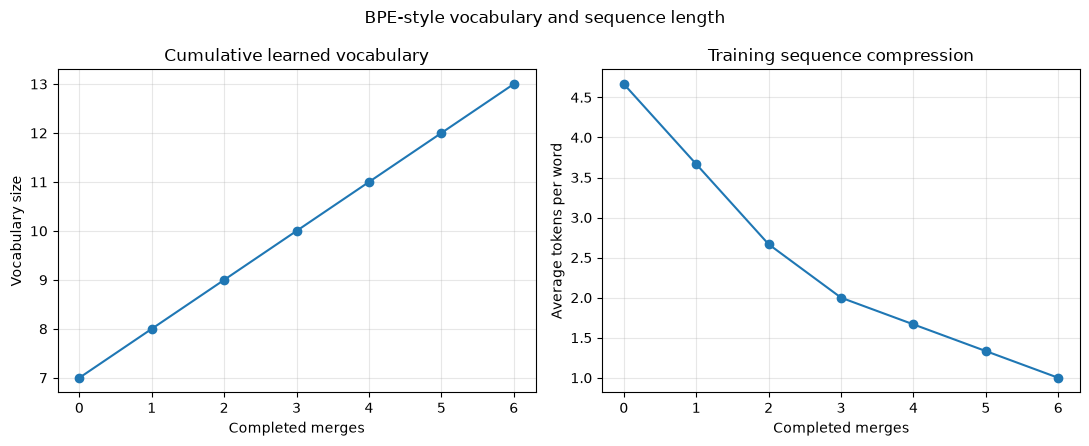

In [6]:
import matplotlib.pyplot as plt

merge_steps = list(range(len(tokenizer_result.vocabulary_sizes)))
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(merge_steps, tokenizer_result.vocabulary_sizes, marker="o")
axes[0].set_title("Cumulative learned vocabulary")
axes[0].set_ylabel("Vocabulary size")
axes[1].plot(merge_steps, tokenizer_result.average_sequence_lengths, marker="o")
axes[1].set_title("Training sequence compression")
axes[1].set_ylabel("Average tokens per word")
for axis in axes:
    axis.set_xlabel("Completed merges")
    axis.grid(alpha=0.3)
figure.suptitle("BPE-style vocabulary and sequence length")
figure.tight_layout()
plt.show()

## Merge order is part of the tokenizer

A later rule may depend on a token created by an earlier rule.

For example, `('lo', 'w')` cannot match until `('l', 'o')` has produced `lo`.

The merge list is therefore an ordered encoding program rather than an unordered vocabulary of pair facts.

In [7]:
def encode_with_merge_rules(text: str, merge_rules: list[MergeRule]) -> list[str]:
    tokens = list(text)
    for rule in merge_rules:
        tokens, _ = merge_pair_in_sequence(tokens, rule.pair, rule.new_token)
    return tokens


def encode_with_reversed_rules(text: str, merge_rules: list[MergeRule]) -> list[str]:
    tokens = list(text)
    for rule in reversed(merge_rules):
        tokens, _ = merge_pair_in_sequence(tokens, rule.pair, rule.new_token)
    return tokens


for text in ["low", "lower", "lowest", "slowest"]:
    encoded = encode_with_merge_rules(text, tokenizer_result.merge_rules)
    print(f"{text!r} -> {encoded} -> {''.join(encoded)!r}")

correct_order = encode_with_merge_rules("lowest", tokenizer_result.merge_rules)
reversed_order = encode_with_reversed_rules("lowest", tokenizer_result.merge_rules)
print("correct order:", correct_order)
print("reversed order:", reversed_order)
print("orders differ:", correct_order != reversed_order)

'low' -> ['low'] -> 'low'
'lower' -> ['lower'] -> 'lower'
'lowest' -> ['lowest'] -> 'lowest'
'slowest' -> ['s', 'lowest'] -> 'slowest'
correct order: ['lowest']
reversed order: ['lo', 'w', 'e', 's', 't']
orders differ: True


The unseen word `slowest` can reuse learned pieces because all of its starting characters occur in the training alphabet.

Joining tokens decodes this toy representation exactly because every merged token is the literal concatenation of its parts.

Production decoding may also need byte decoding, normalization conventions, and special-token handling.

## Convert learned tokens to IDs

A GPT consumes integer IDs, so the cumulative vocabulary needs a stable token-to-ID mapping.

This teaching mapping sorts token strings for deterministic IDs.

An unseen starting character remains after all merges and must trigger a clear error instead of an accidental dictionary failure.

In [8]:
def build_token_to_id(vocabulary: set[str]) -> dict[str, int]:
    return {token: token_id for token_id, token in enumerate(sorted(vocabulary))}


def encode_to_token_ids(
    text: str, merge_rules: list[MergeRule], token_to_id: dict[str, int]
) -> list[int]:
    tokens = encode_with_merge_rules(text, merge_rules)
    unknown_tokens = sorted(set(tokens) - set(token_to_id))
    if unknown_tokens:
        raise ValueError(f"tokens are outside the learned vocabulary: {unknown_tokens}")
    return [token_to_id[token] for token in tokens]


def decode_token_ids(token_ids: list[int], id_to_token: dict[int, str]) -> str:
    unknown_ids = sorted(set(token_ids) - set(id_to_token))
    if unknown_ids:
        raise ValueError(f"token IDs are outside the vocabulary: {unknown_ids}")
    return "".join(id_to_token[token_id] for token_id in token_ids)


token_to_id = build_token_to_id(tokenizer_result.vocabulary)
id_to_token = {token_id: token for token, token_id in token_to_id.items()}
text = "slowest"
token_ids = encode_to_token_ids(text, tokenizer_result.merge_rules, token_to_id)
print("token-to-ID vocabulary:", token_to_id)
print("text:", text)
print("tokens:", encode_with_merge_rules(text, tokenizer_result.merge_rules))
print("token IDs:", token_ids)
print("decoded:", decode_token_ids(token_ids, id_to_token))

try:
    encode_to_token_ids("glow", tokenizer_result.merge_rules, token_to_id)
except ValueError as error:
    print("unseen-character check:", error)

token-to-ID vocabulary: {'e': 0, 'l': 1, 'lo': 2, 'low': 3, 'lowe': 4, 'lower': 5, 'lowes': 6, 'lowest': 7, 'o': 8, 'r': 9, 's': 10, 't': 11, 'w': 12}
text: slowest
tokens: ['s', 'lowest']
token IDs: [10, 7]
decoded: slowest
unseen-character check: tokens are outside the learned vocabulary: ['g']


## Word boundaries and spaces require a policy

Training separate word sequences prevents merges across boundaries but requires another system to represent spaces and reassemble text.

Training on complete text makes spaces ordinary starting tokens that can participate in merges.

Other BPE-style systems attach an end-of-word marker or encode a leading-space convention.

For example, a marked word might begin as `l o w </w>`, allowing word-final pieces to differ from the same letters inside a longer word.

None of these policies is implicit in pair merging, so training and encoding must use the same one.

## Why tie-breaking changes later merges

In the initial tiny corpus, `(l, o)` and `(o, w)` both occur three times.

Choosing `(l, o)` creates `lo`, which makes `(lo, w)` available.

Choosing `(o, w)` instead creates `ow`, which makes `(l, ow)` available.

Both can eventually represent the same text, but their intermediate symbols and later pair statistics differ.

A tokenizer artifact must therefore preserve both merge order and the tie-breaking procedure used during training.

## What this toy trainer omits

A production tokenizer needs decisions beyond the merge loop:

- bytes or Unicode normalization as the starting representation;
- corpus frequencies and scalable counting;
- whitespace and document boundaries;
- reserved and special tokens;
- unknown-symbol or byte-fallback behavior;
- deterministic serialization;
- exact encode-decode tests; and
- efficient longest-sequence processing.

BPE learns frequent surface patterns, not semantic definitions.

More merges shorten the training segmentation but also enlarge model embedding and output vocabularies.

## Common mistakes

- Do not treat merge rules as an unordered set.
- Do not rely on an undocumented tie-break.
- Do not confuse overlapping pair counts with non-overlapping replacements.
- Do not report only currently visible tokens as the learned vocabulary.
- Do not train on isolated words and silently encode full text under different boundary rules.
- Do not assume unseen starting characters have token IDs.
- Do not call this character-initialized teaching implementation byte-level production BPE.
- Do not assume more merges always improve a downstream language model.

## Takeaways

BPE-style training repeatedly counts adjacent pairs, selects one frequent pair, and replaces its non-overlapping occurrences.

Each learned rule adds a reusable token and becomes one ordered encoding instruction.

Cumulative vocabulary grows while training sequences shrink.

Tie-breaking, starting symbols, boundaries, and unknown-symbol policy are part of the tokenizer definition.

> Encoding must replay the same ordered merge program learned under the same preprocessing and boundary rules.

## What comes next

The next chapter can replace character IDs in GPT batches with IDs from this learned subword vocabulary.

That connection changes vocabulary-dependent model dimensions and sequence lengths while preserving the causal next-token training objective.